### Testing Covariance between SSC (via turbidity) and VHF 

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr


sp_turb = pd.read_csv('../../data/SSC/turb_SP23_clean_complete.csv', index_col=0, parse_dates=True).dropna()
sm_turb = pd.read_csv('../../data/SSC/turb_SM23_clean_complete.csv', index_col=0, parse_dates=True).dropna()
VHF_spring = pd.read_csv('../../data/hyporheic_fluxes/spring_HF.csv', index_col=0, parse_dates=True).dropna()
VHF_summer = pd.read_csv('../../data/hyporheic_fluxes/summer_HF.csv', index_col=0, parse_dates=True).dropna()

# deal with duplicates
sm_turb = sm_turb[~sm_turb.index.duplicated(keep='first')]
sp_turb = sp_turb[~sp_turb.index.duplicated(keep='first')]
# resample to have same timestamps in turbidity 
sp_turb = sp_turb.resample('1min').interpolate()
sm_turb = sm_turb.resample('1min').interpolate()

VHF_spring = VHF_spring.loc['2023-04-18':'2023-05-05']
VHF_summer = VHF_summer.loc['2023-07-05':'2023-09-20']

# merge on dates
spring = VHF_spring.merge(sp_turb, left_index=True, right_index=True, how='inner')
summer = VHF_summer.merge(sm_turb, left_index=True, right_index=True, how='inner')

In [20]:
spring

,T1,T2,T3,T5,T6,T7,T8,TurbClean
2023-04-18 00:00:00,0.000003,-0.000002,-2.780000e-07,6.770000e-07,-4.830000e-07,-3.790000e-06,-2.530000e-07,12.542787
2023-04-18 00:15:00,0.000003,-0.000002,-2.790000e-07,6.740000e-07,-4.860000e-07,-3.790000e-06,-2.570000e-07,12.183833
2023-04-18 00:30:00,0.000003,-0.000003,-2.820000e-07,6.700000e-07,-4.880000e-07,-3.800000e-06,-2.610000e-07,14.095209
2023-04-18 00:45:00,0.000003,-0.000003,-2.840000e-07,6.670000e-07,-4.910000e-07,-3.810000e-06,-2.640000e-07,11.757029
2023-04-18 01:00:00,0.000003,-0.000003,-2.870000e-07,6.630000e-07,-4.940000e-07,-3.820000e-06,-2.680000e-07,11.934281
...,...,...,...,...,...,...,...,...
2023-05-05 22:45:00,0.000002,-0.000003,-2.010000e-06,7.980000e-07,-4.860000e-07,-2.350000e-07,-4.140000e-07,2.003648
2023-05-05 23:00:00,0.000002,-0.000003,-2.010000e-06,7.980000e-07,-4.880000e-07,-2.310000e-07,-4.160000e-07,1.975677
2023-05-05 23:15:00,0.000002,-0.000003,-2.020000e-06,7.980000e-07,-4.910000e-07,-2.290000e-07,-4.180000e-07,1.970949
2023-05-05 23:30:00,0.000002,-0.000003,-2.020000e-06,7.980000e-07,-4.930000e-07,-2.270000e-07,-4.190000e-07,1.924388


Plot relationsships for each probe 

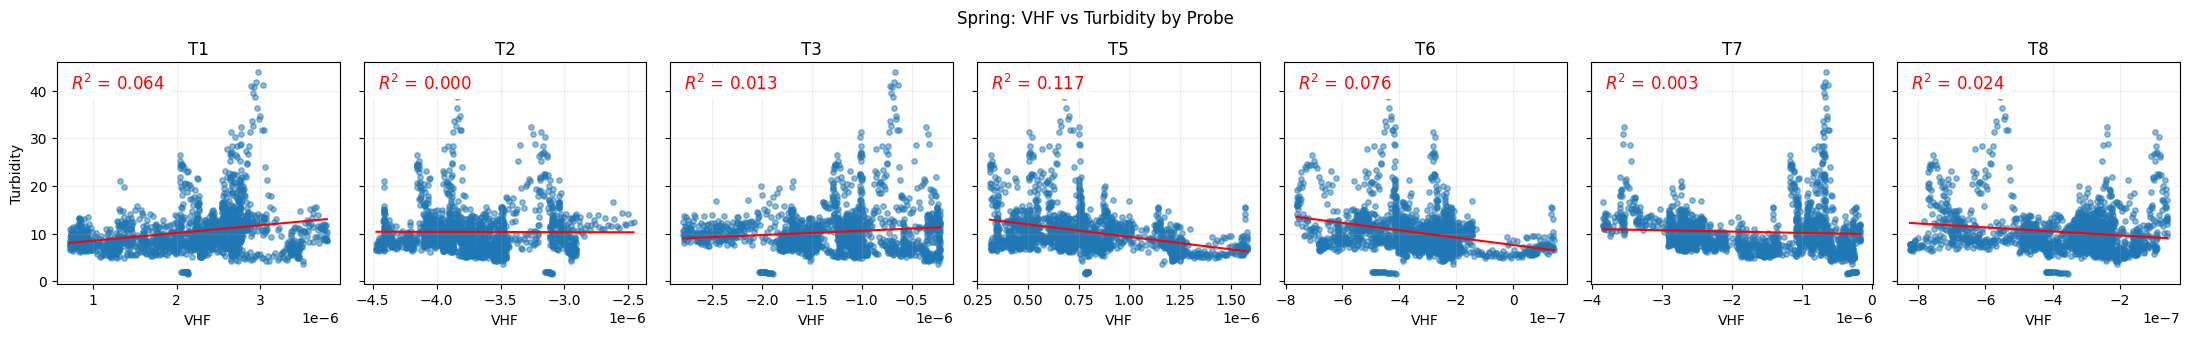

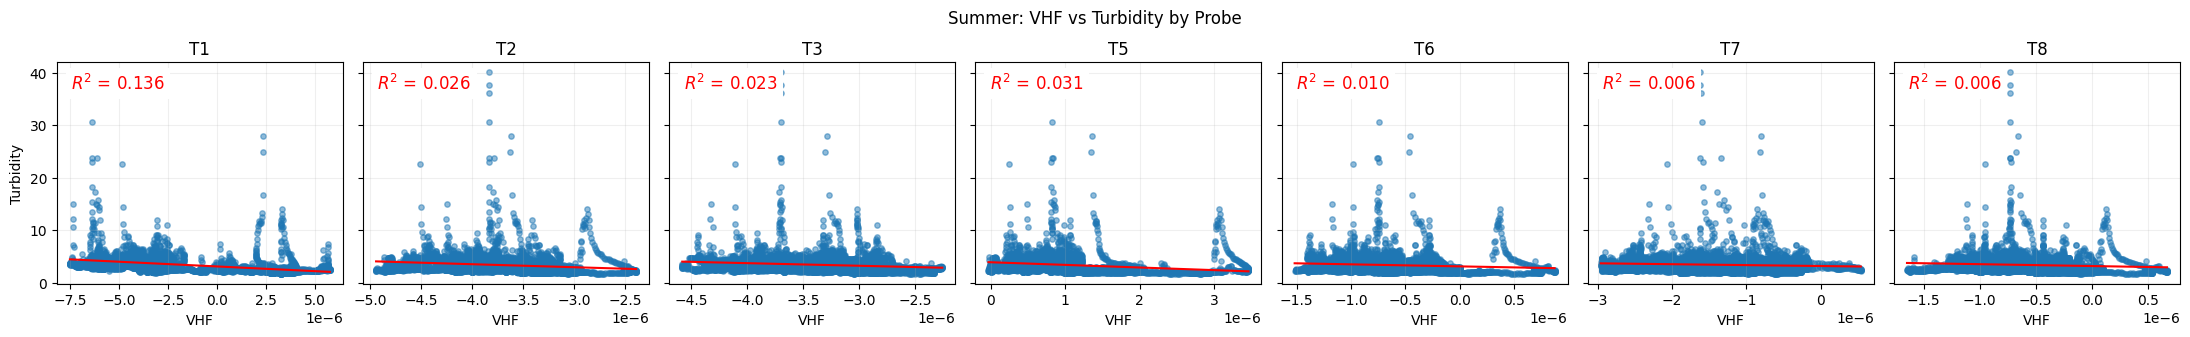

In [21]:
probes = ['T1', 'T2', 'T3', 'T5', 'T6', 'T7', 'T8']

def plot_probe_row(data, title):
    fig, axes = plt.subplots(1, len(probes), figsize=(22, 3.5), sharey=True)
    for ax, probe in zip(axes, probes):
        x = data[probe]
        y = data['TurbClean']
        valid = x.notna() & y.notna()
        x_valid = x[valid]
        y_valid = y[valid]

        ax.scatter(x_valid, y_valid, alpha=0.5, s=15)

        if valid.sum() > 1:
            m, b = np.polyfit(x_valid, y_valid, 1)
            x_line = np.linspace(x_valid.min(), x_valid.max(), 100)
            y_line = m * x_line + b
            ax.plot(x_line, y_line, color='red')

            y_pred = m * x_valid + b
            ss_res = np.sum((y_valid - y_pred) ** 2)
            ss_tot = np.sum((y_valid - y_valid.mean()) ** 2)
            r2 = 1 - (ss_res / ss_tot) if ss_tot != 0 else np.nan

            ax.text(0.05, 0.95, f"$R^2$ = {r2:.3f}", transform=ax.transAxes, ha='left', va='top', color='red', 
                    fontsize=12, bbox=dict(facecolor='white', edgecolor='none'))
        ax.set_title(probe)
        ax.set_xlabel('VHF')
        ax.grid(True, alpha=0.2)

    axes[0].set_ylabel('Turbidity')
    fig.suptitle(title, y=0.95)
    fig.tight_layout()
    plt.show()

plot_probe_row(spring, 'Spring: VHF vs Turbidity by Probe')
plot_probe_row(summer, 'Summer: VHF vs Turbidity by Probe')

Calculate covariance, and correlation coefficients

In [22]:
probes = ['T1', 'T2', 'T3', 'T5', 'T6', 'T7', 'T8']

# COVARIANCE 
# spring
spring_covariances = {}
for probe in probes:
    cov = spring[probe].cov(spring['TurbClean'])
    spring_covariances[probe] = cov
# summer 
summer_covariances = {}
for probe in probes:
    cov = summer[probe].cov(summer['TurbClean'])
    summer_covariances[probe] = cov


# PEARSON CORRELATION 
# spring
spring_pearson = {}
for probe in probes:
    pearson_r, p_value = pearsonr(spring[probe], spring['TurbClean'])
    spring_pearson[probe] = (pearson_r, p_value)
# summer
summer_pearson = {}
for probe in probes:
    pair = summer[[probe, 'TurbClean']]
    if len(pair) < 2 or pair[probe].nunique() < 2 or pair['TurbClean'].nunique() < 2:
        summer_pearson[probe] = (np.nan, np.nan)
        continue
    pearson_r, p_value = pearsonr(summer[probe], summer['TurbClean'])
    summer_pearson[probe] = (pearson_r, p_value)

# SPEARMAN CORRELATION
# spring
spring_spearman = {}
for probe in probes:
    spearman_rho, p_value = spearmanr(spring[probe], spring['TurbClean'])
    spring_spearman[probe] = (spearman_rho, p_value)
# summer
summer_spearman = {}
for probe in probes:
    pair = summer[[probe, 'TurbClean']]
    if len(pair) < 2 or pair[probe].nunique() < 2 or pair['TurbClean'].nunique() < 2:
        summer_spearman[probe] = (np.nan, np.nan)
        continue
    spearman_rho, p_value = spearmanr(summer[probe], summer['TurbClean'])
    summer_spearman[probe] = (spearman_rho, p_value)

# add all spring and summer results to a dataframe
spring_results = pd.DataFrame({
    'Probe': probes,
    'Covariance': [spring_covariances[probe] for probe in probes],
    'Pearson_r': [spring_pearson[probe][0] for probe in probes],
    'Pearson_p': [spring_pearson[probe][1] for probe in probes],
    'Spearman_rho': [spring_spearman[probe][0] for probe in probes],
    'Spearman_p': [spring_spearman[probe][1] for probe in probes],
    "r2": [spring[probe].corr(spring['TurbClean'])**2 for probe in probes]
})

summer_results = pd.DataFrame({
    'Probe': probes,
    'Covariance': [summer_covariances[probe] for probe in probes],
    'Pearson_r': [summer_pearson[probe][0] for probe in probes],
    'Pearson_p': [summer_pearson[probe][1] for probe in probes],
    'Spearman_rho': [summer_spearman[probe][0] for probe in probes],
    'Spearman_p': [summer_spearman[probe][1] for probe in probes],
    "r2": [summer[probe].corr(summer['TurbClean'])**2 for probe in probes]
})

In [23]:
spring_results

,Probe,Covariance,Pearson_r,Pearson_p,Spearman_rho,Spearman_p,r2
0,T1,9.408579e-07,0.253163,1.123916e-26,0.287604,2.900879e-34,0.064092
1,T2,-9.580721e-09,-0.004777,8.426939e-01,-0.070259,3.476823e-03,0.000023
2,T3,3.458143e-07,0.114788,1.718284e-06,0.010370,6.666229e-01,0.013176
3,T5,-5.295473e-07,-0.341544,1.818305e-48,-0.406681,8.192371e-70,0.116652
4,T6,-2.347790e-07,-0.276057,1.349406e-31,-0.344397,2.659694e-49,0.076207
5,T7,-2.732694e-07,-0.056051,1.979953e-02,-0.218625,3.823936e-20,0.003142
6,T8,-1.372633e-07,-0.155160,8.902419e-11,-0.153064,1.596467e-10,0.024075


In [27]:
print(spring_results["r2"].min())
print(spring_results["r2"].max())

2.2823244298205703e-05
0.11665230601271151


In [25]:
summer_results

,Probe,Covariance,Pearson_r,Pearson_p,Spearman_rho,Spearman_p,r2
0,T1,-1.995014e-06,-0.368827,1.989323e-234,-0.606364,0.000000e+00,0.136034
1,T2,-1.204874e-07,-0.161860,4.149077e-44,-0.342684,1.390705e-200,0.026199
2,T3,-1.217629e-07,-0.151737,6.480656e-39,-0.278904,9.567497e-131,0.023024
3,T5,-1.642544e-07,-0.176710,2.307392e-52,-0.397220,6.223022e-275,0.031227
4,T6,-6.479692e-08,-0.097742,5.450718e-17,-0.216923,1.330839e-78,0.009553
5,T7,-9.576032e-08,-0.079172,1.205767e-11,-0.104541,3.177426e-19,0.006268
6,T8,-4.659493e-08,-0.079360,1.078258e-11,-0.183664,1.718151e-56,0.006298


In [28]:
print(summer_results["r2"].min())
print(summer_results["r2"].max())

0.006268236351415233
0.1360336321910482


In [7]:
spring_results.to_csv('spring_VHF_turbidity_covariance_results.csv', index=False)
summer_results.to_csv('summer_VHF_turbidity_covariance_results.csv', index=False)

Cross-correlations

In [8]:
def cross_corr_lag(data, probes, target='TurbClean'):
    results = []

    for probe in probes:
        pair = data[[probe, target]].dropna()
        if len(pair) < 2:
            results.append({
                'Probe': probe,
                'Best_lag_min': np.nan,
                'Max_correlation': np.nan
            })
            continue

        x = (pair[probe] - pair[probe].mean()) / pair[probe].std()
        y = (pair[target] - pair[target].mean()) / pair[target].std()

        ccf = np.correlate(x, y, mode='full')
        lags = np.arange(-len(x) + 1, len(x))

        best_idx = np.argmax(ccf)
        best_lag = lags[best_idx]

        results.append({
            'Probe': probe,
            'Best_lag_min': best_lag,
            'Max_correlation': ccf[best_idx]
        })

    return pd.DataFrame(results)

spring_lags = cross_corr_lag(spring, probes)
summer_lags = cross_corr_lag(summer, probes)
spring_lags

,Probe,Best_lag_min,Max_correlation
0,T1,-118,671.163085
1,T2,-407,387.011004
2,T3,-155,558.970663
3,T5,-410,769.794702
4,T6,-410,739.193677
5,T7,-410,417.576744
6,T8,-413,552.441386


In [9]:
summer_lags

,Probe,Best_lag_min,Max_correlation
0,T1,4884,2205.980735
1,T2,4647,1097.134621
2,T3,-3518,1162.670232
3,T5,4583,1692.600318
4,T6,4654,940.259425
5,T7,2509,841.476602
6,T8,4656,788.786047


## Testing for absolute values

In [10]:
spring = np.abs(spring)
summer = np.abs(summer)

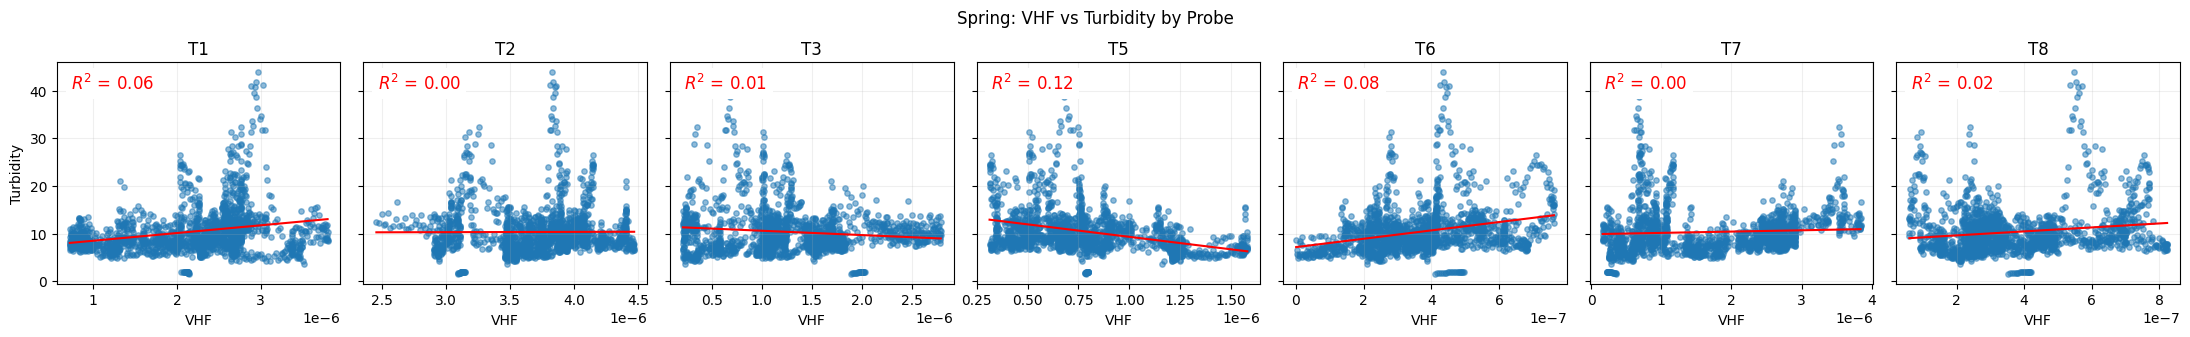

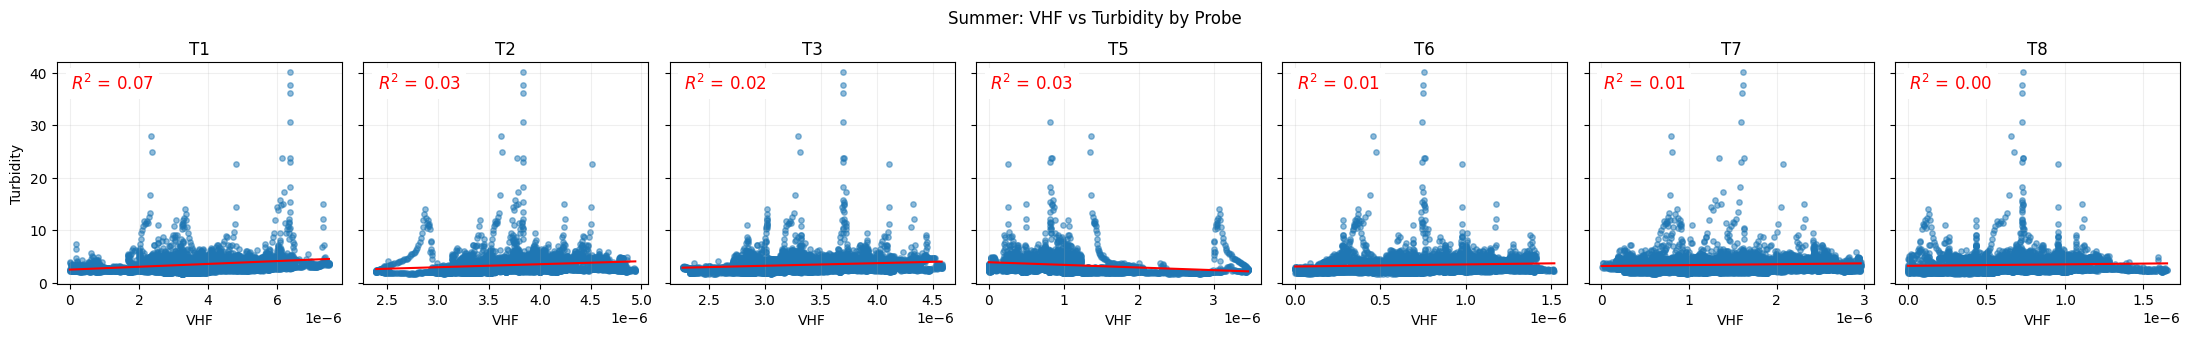

In [11]:
probes = ['T1', 'T2', 'T3', 'T5', 'T6', 'T7', 'T8']

def plot_probe_row(data, title):
    fig, axes = plt.subplots(1, len(probes), figsize=(22, 3.5), sharey=True)
    for ax, probe in zip(axes, probes):
        x = data[probe]
        y = data['TurbClean']
        valid = x.notna() & y.notna()
        x_valid = x[valid]
        y_valid = y[valid]

        ax.scatter(x_valid, y_valid, alpha=0.5, s=15)

        if valid.sum() > 1:
            m, b = np.polyfit(x_valid, y_valid, 1)
            x_line = np.linspace(x_valid.min(), x_valid.max(), 100)
            y_line = m * x_line + b
            ax.plot(x_line, y_line, color='red')

            y_pred = m * x_valid + b
            ss_res = np.sum((y_valid - y_pred) ** 2)
            ss_tot = np.sum((y_valid - y_valid.mean()) ** 2)
            r2 = 1 - (ss_res / ss_tot) if ss_tot != 0 else np.nan

            ax.text(0.05, 0.95, f"$R^2$ = {r2:.2f}", transform=ax.transAxes, ha='left', va='top', color='red', 
                    fontsize=12, bbox=dict(facecolor='white', edgecolor='none'))
        ax.set_title(probe)
        ax.set_xlabel('VHF')
        ax.grid(True, alpha=0.2)

    axes[0].set_ylabel('Turbidity')
    fig.suptitle(title, y=0.95)
    fig.tight_layout()
    plt.show()

plot_probe_row(spring, 'Spring: VHF vs Turbidity by Probe')
plot_probe_row(summer, 'Summer: VHF vs Turbidity by Probe')

In [12]:
probes = ['T1', 'T2', 'T3', 'T5', 'T6', 'T7', 'T8']

# COVARIANCE 
# spring
spring_covariances = {}
for probe in probes:
    cov = spring[probe].cov(spring['TurbClean'])
    spring_covariances[probe] = cov
# summer 
summer_covariances = {}
for probe in probes:
    cov = summer[probe].cov(summer['TurbClean'])
    summer_covariances[probe] = cov


# PEARSON CORRELATION 
# spring
spring_pearson = {}
for probe in probes:
    pearson_r, p_value = pearsonr(spring[probe], spring['TurbClean'])
    spring_pearson[probe] = (pearson_r, p_value)
# summer
summer_pearson = {}
for probe in probes:
    pearson_r, p_value = pearsonr(summer[probe], summer['TurbClean'])
    summer_pearson[probe] = (pearson_r, p_value)

# SPEARMAN CORRELATION
# spring
spring_spearman = {}
for probe in probes:
    spearman_rho, p_value = spearmanr(spring[probe], spring['TurbClean'])
    spring_spearman[probe] = (spearman_rho, p_value)
# summer
summer_spearman = {}
for probe in probes:
    spearman_rho, p_value = spearmanr(summer[probe], summer['TurbClean'])
    summer_spearman[probe] = (spearman_rho, p_value)

# add all spring and summer results to a dataframe
spring_results = pd.DataFrame({
    'Probe': probes,
    'Covariance': [spring_covariances[probe] for probe in probes],
    'Pearson_r': [spring_pearson[probe][0] for probe in probes],
    'Pearson_p': [spring_pearson[probe][1] for probe in probes],
    'Spearman_rho': [spring_spearman[probe][0] for probe in probes],
    'Spearman_p': [spring_spearman[probe][1] for probe in probes]
})

summer_results = pd.DataFrame({
    'Probe': probes,
    'Covariance': [summer_covariances[probe] for probe in probes],
    'Pearson_r': [summer_pearson[probe][0] for probe in probes],
    'Pearson_p': [summer_pearson[probe][1] for probe in probes],
    'Spearman_rho': [summer_spearman[probe][0] for probe in probes],
    'Spearman_p': [summer_spearman[probe][1] for probe in probes]
})

In [13]:
spring_results

,Probe,Covariance,Pearson_r,Pearson_p,Spearman_rho,Spearman_p
0,T1,9.408579e-07,0.253163,1.123916e-26,0.287604,2.900879e-34
1,T2,9.580721e-09,0.004777,8.426939e-01,0.070259,3.476823e-03
2,T3,-3.458143e-07,-0.114788,1.718284e-06,-0.010370,6.666229e-01
3,T5,-5.295473e-07,-0.341544,1.818305e-48,-0.406681,8.192371e-70
4,T6,2.121150e-07,0.279937,1.769495e-32,0.347314,3.648388e-50
5,T7,2.732694e-07,0.056051,1.979953e-02,0.218625,3.823936e-20
6,T8,1.372633e-07,0.155160,8.902419e-11,0.153064,1.596467e-10


In [14]:
summer_results

,Probe,Covariance,Pearson_r,Pearson_p,Spearman_rho,Spearman_p
0,T1,7.264312e-07,0.273576,1.118118e-125,0.390942,1.256279e-265
1,T2,1.204874e-07,0.161860,4.149077e-44,0.342684,1.390705e-200
2,T3,1.217629e-07,0.151737,6.480656e-39,0.278904,9.567497e-131
3,T5,-1.644253e-07,-0.177001,1.563210e-52,-0.397243,5.756389e-275
4,T6,4.248328e-08,0.080114,6.867542e-12,0.191165,3.912191e-61
5,T7,8.918555e-08,0.075642,9.396512e-11,0.102115,2.072889e-18
6,T8,2.764352e-08,0.054571,3.025480e-06,0.165909,2.770660e-46


In [15]:
spring_results.to_csv('spring_absVHF_turbidity_covariance_results.csv', index=False)
summer_results.to_csv('summer_absVHF_turbidity_covariance_results.csv', index=False)